# 1. Exploratory Analysis of Netflix Shows and Movies

The dataset consists of details about the movies and tv shows such as the title, director, and cast of the shows / movies. The aim here is to assist in the analysis of the growth of Netflix content over the years and help in identifying key patterns. In this research, we considered key features of the content, which included content type (Movies, TV Shows), genres, ratings, countries, and years of release. Line charts, bar charts, and area charts were used for better visualization of the trends. For example, the research also shows the growth in content after 2015, the most popular genres, and countries with the most content.

The target audience is film industry contributor such as producers, directors, and marketing teams interested in improving content and user engagement.The main target is to support better decision-making by finding patterns and understand key trends in Netflix content like content distribution, popular types and audience rating. also This it helps transform raw data into useful information for improving content strategy and business planning.


Dataset URL:[Click here](https://www.kaggle.com/datasets/ranaghulamnabi/netflix-movies-and-tv-shows-dataset/data)

## Data Exploration and Data Quality

This dataset have information about movies and TV shows such as title, type, cast, country, rating, duration, and date added. During exploration, some data quality problem were found. There are missing values in columns like director, cast, and country. Some columns have multiple values in one cell (e.g., cast and genres), and in the duration column, minutes and seasons are mixed. Also, the date_added column is in text format.

To improve the quality of the dataset, the missing values can be filled, the columns can be separated in the appropriate format, the duration column can be improved, and the date added column can be changed from text type to datetime type, which makes the dataset ready for analysis.


In [44]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import squarify
import warnings
warnings.filterwarnings("ignore")

#  2. Data Exploration and Preprocessing


In [45]:
df = pd.read_csv(r"C:\new\netflix_titles.csv")
df.dropna(inplace=True)

In [46]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [47]:
df.shape
df = df.reset_index(drop=True)

# Convert date strings to datetime objects and extract the year
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

# filter movies
df_movies = df[df['type'] == 'Movie'].copy()

# clean duration (convert to number)
df_movies['duration'] = df_movies['duration'].str.extract('(\d+)').astype(float)

country_counts = df['country'].value_counts().head(10).reset_index()
country_counts.columns = ['country', 'count']

# split genres and count
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(20)

top_cast = df['cast'].str.split(', ').explode().value_counts().head(10)

df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0
1,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,2021.0
2,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0
3,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021.0
4,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,2021-09-21,1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...,2021.0


# 3. Explanatory Data Visualization Insights
## Insight 1: Content Growth and Their Importance.

The line chart indicates how Netflix content has been changing over time for both movies and TV shows.

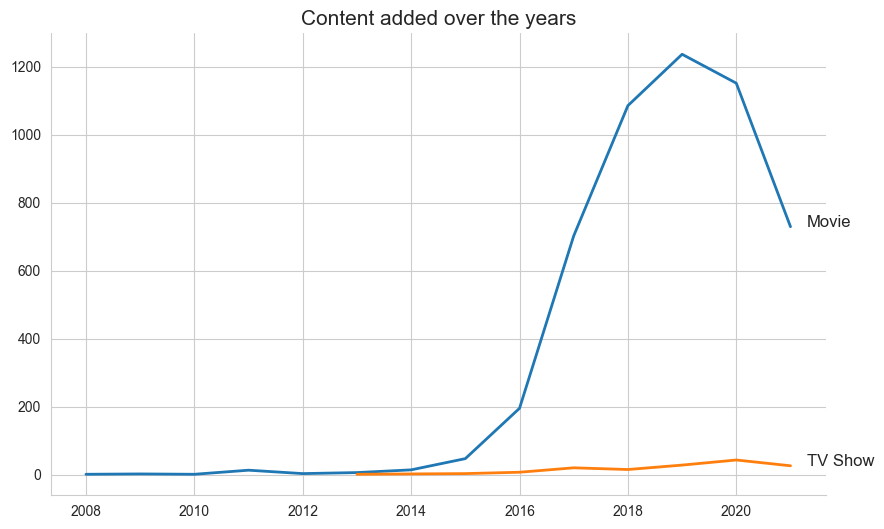

In [48]:
data = df.groupby(['year_added', 'type']).size().reset_index(name='count')

plt.figure(figsize=(10,6))
ax = sns.lineplot(data=data, x='year_added', y='count',
                  hue='type', linewidth=2)

sns.despine()
for line, label in zip(ax.lines, data['type'].unique()):
    x = line.get_xdata()[-1]
    y = line.get_ydata()[-1]
    plt.text(x+0.3, y, label, fontsize=12)
    
plt.title("Content added over the years", fontsize=15)
plt.xlabel("")
plt.ylabel("")
sns.set_style("white")
ax.legend().remove()
plt.show()

In the code, the date_added column is changed to datetime to access useful information such as the year. Next, the data is grouped based on the year_added and type (Movie and TV Show) to find the count of the data that was added in a particular year. 

In this line chart, it can clearly understand that the content started growing significantly after 2015. Movies show a faster growth more than TV shows, after 2016 up to 2019. we can understand that Netflix focused more on adding movies to their titles more than TV shows during that time period.

- Importance of the Insight for Business

The importance of this insight for the business is that it shows the growth pattern adopted by Netflix for their business. From the growth of movies, we understand that movies play a important role in hold users for the business. At the end, we understand that Netflix is making better decisions for their business to remain competitive in the industry.
 


## Insight 2. Distribution of Movie Duration
The histogram shows how movie durations are distributed across different time ranges on Netflix.

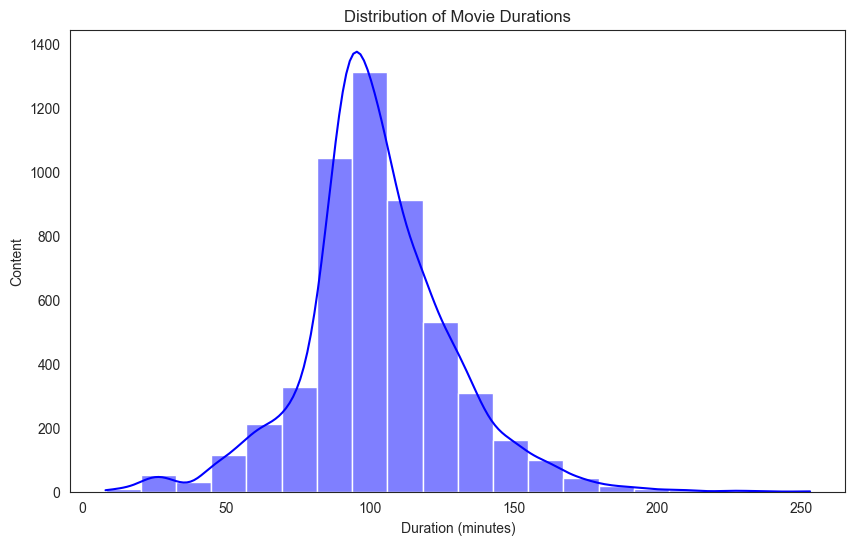

In [49]:
plt.figure(figsize=(10,6))
sns.histplot(df_movies['duration'],
             bins=20,
             kde=True,
             color='blue',
             alpha=0.5)


plt.xlabel("Duration (minutes)")
plt.ylabel("Content")
plt.title("Distribution of Movie Durations")
plt.show()

first of all, filter the data so it only include movie information. after clean the duration column of the data so it is in proper format. then, we create a histogram showing a curve for movie duration distribution. 

From this analysis, we can understand that most of the movies are of duration 80-120 minutes, with a peak at 90-100 minutes. This indicates that Netflix movies are of standard duration, with very short or very long duration movies being exceptions. 

- Importance of the Insight for Business

This insight helps Netflix to understand the preferred movie length for users. Most movies are around 90–100 minutes, it show this duration is more engaging. Netflix can use this information to produce future content that matches audience attention, which can improve user satisfaction and increase viewing time.

## Insight 3: Content Contribution by top Country
The treemap shows how different countries contribute to Netflix content.

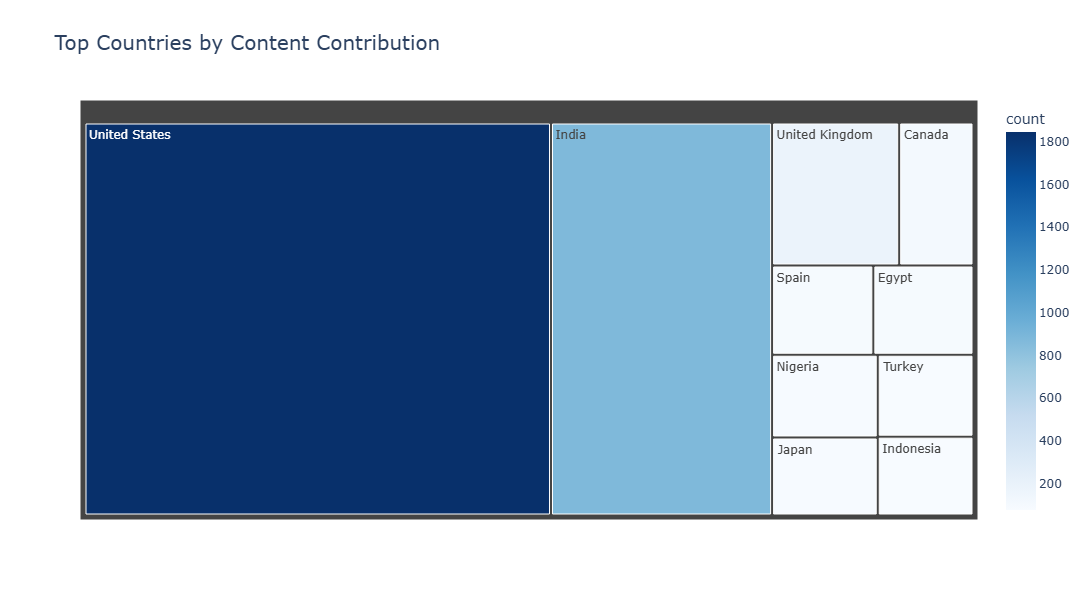

In [50]:
fig = px.treemap(
    country_counts,
    path=['country'],
    values='count',
    color='count',
    color_continuous_scale='Blues',
    title="Top Countries by Content Contribution"
)


fig.update_layout(
        height=600,
        title_font_size=20
)

fig.show()

In the code, the data have grouped by country to count how many titles each country create. Then, Plotly has used to create treemap where eaery box represents a country, and size of the box shows number of titles. The color also represents the count, making it help to compare countries.

From the chart, it have to see that the United States contributes the highest number of titles, followed by India and the United Kingdom. Other countries like Canada, Spain, and Japan contribute smaller. This shows that Netflix content is heavily leading by a few countries, especially United States.

- Importance of the Insight for Business

it helps Netflix understand where most of its content is coming from. Netflix can use this insight to increase content from other countries to attract more users globaly. This can help increase users from different countries and improve user attentions. This insight can help improve decision-making for content investment method.

## Insight 4: Top Genres on Netflix
The bar chart shows that dramas, comedies, and international movies are the most popular categories on Netflix.

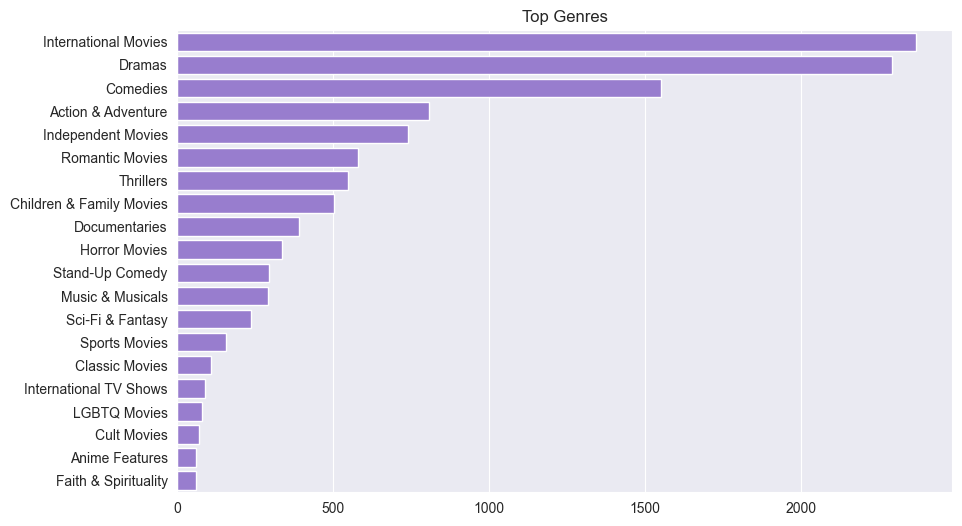

In [51]:
plt.figure(figsize=(10,6))
sns.set_style("darkgrid")

sns.barplot(x=top_genres.values, y=top_genres.index, color='mediumpurple')

plt.title("Top Genres")
plt.xlabel("")
plt.ylabel("")

plt.show()

code is splitting the listed_in column into different genres and then exploding them. Then, the frequency of each genre is found and the top ones selected. Finally,a horizontal bar chart is plotted to easily see the most popular ones.

In this chart, International Movies, Dramas, and Comedies are the most popular categorie on Netflix. Other categories like Action & Adventure and Independent Movies are also very popular. However, there are also some with less numbers. it show Netflix offers a wide variety of different genres to its viewers but prefer on a few.

- Importance of the Insight for Business

it will help them know what genre of movies is most popular among their viewers. This prove they will be able to come up with even more engaging content for their viewers. This will attract even more viewers to their platform.

## Insight 5: Movie Duration Distribution by Rating
The box plot shows how movie durations are distributed across different rating categories, including the median, spread, and outliers for each rating.

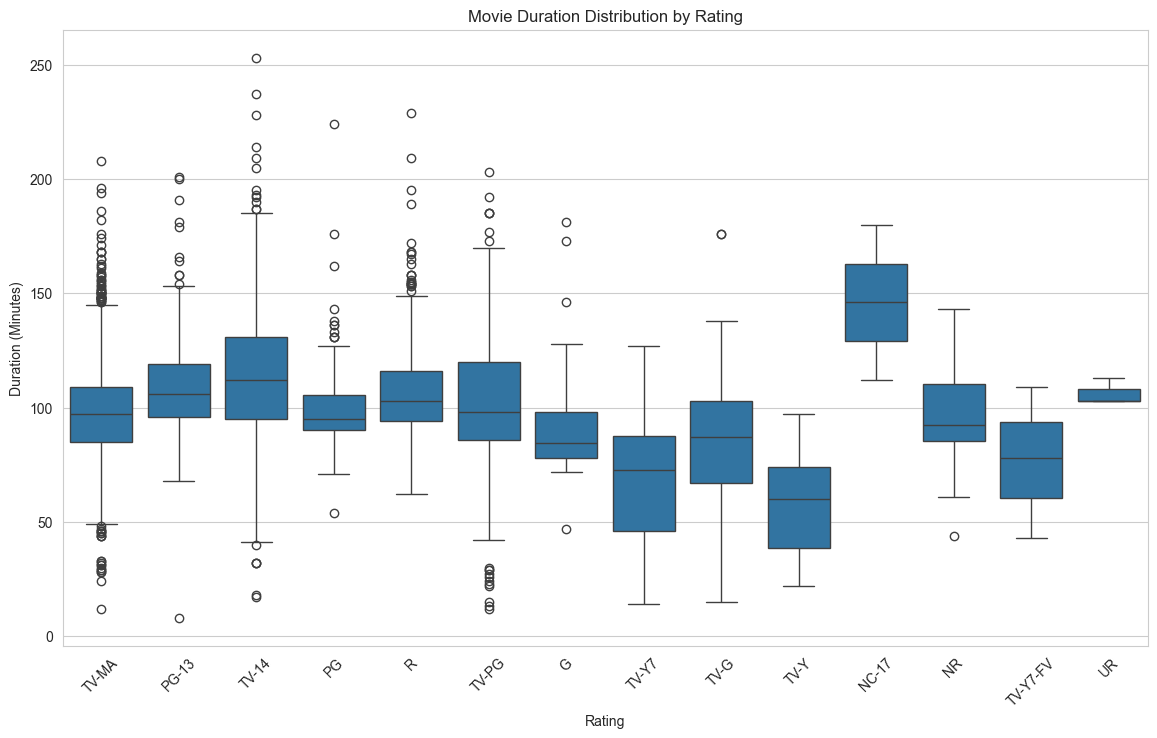

In [52]:
df_movies = df_movies.dropna(subset=['duration', 'rating'])
sns.set_style("whitegrid")

plt.figure(figsize=(14,8))
sns.boxplot(data=df_movies, x='rating', y='duration')

plt.title("Movie Duration Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Duration (Minutes)")
plt.xticks(rotation=45)

plt.show()

In code, data need to erase the empty values in the duration and rating. a box plot is created by using of seaborn. In the box plot, the x-axis represents the varies rating categories of movies, and the y-axis represents duration of movies in minutes.

In insight, TV-MA and PG-13 have longer durations more than to TV-Y and TV-G. This prove that some movies are longer than others. while ratings such as TV-Y and TV-G have shorter durations. The difference in the boxes also shows that some ratings have a longer range of movie lengths than others.

- Importance of the Insight for Business
  
this insight shows that kind of viewer affects the length of the movie. Therefore, by using this insight, Netflix has develop its content to prefer the viewer. For example, the length of the movie have be shorter for kids and longer for adults.

## Insight 6: Top 10 Actors on Netflix
The chart shows that top 10 actors appear more frequently on Netflix.

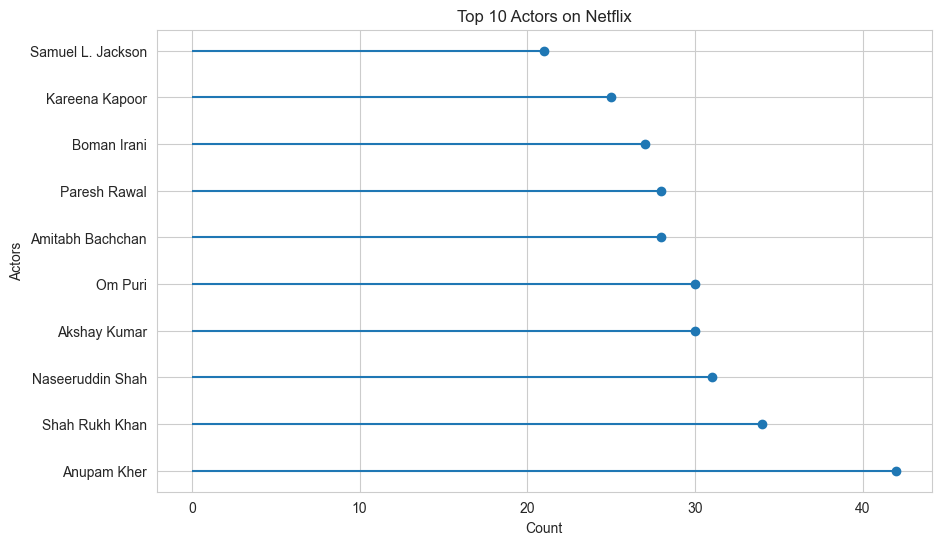

In [53]:
plt.figure(figsize=(10,6))

plt.hlines(y=top_cast.index, xmin=0, xmax=top_cast.values)
plt.plot(top_cast.values, top_cast.index, "o")

plt.title("Top 10 Actors on Netflix")
plt.xlabel("Count")
plt.ylabel("Actors")
plt.show()

Firstly, the cast column has splitting into actor names and expanded using the explode function.Then, each actor have counted, and top 10 actors are selected. A lollipop chart has created to clearly show the number of content for every actor.

From the chart, some actors like Anupam Kher, Shah Rukh Khan, and Naseeruddin Shah are more frequently showed in the movies in Netflix. This prove that some actors have a significant presence in the platform and have been presented in many movies.

- Importance of the Insight for Business

The insight is important to the business as it helps the company understand which actors appear most frequently in its content. The actors who appear most frequently can help the company attract more users to its content. 


## Final Discussion and Conclusion
This analysis is helpful in gaining insights about the content of Netflix using data visualization and simple data processing techniques. The major advantages of this kind of analysis are the use of simple charts to show trends like the increasing amount of content, popular categories, top actors, etc. The data is clean and processed correctly, which helps in generating proper insights from the data. There have negative points as well, like presence of missing information in dataset about user preferences, ratings, and performance, which might have helped in more in-depth analysis of data.

The analysis has indicats that movies constitute the most of Netflix’s content, with a significant increase in content creation has observed after 2015. Moreover, limited categories and actors appear more frequently, indicating clear view in titles distribution and popularity. The variation in movie duration across alternative audience groups further, highlights how content have showed to meet viewer attention. These finding have been provided important insights into content trends and audience attreaction.

Based on all insights, it has recommended that Netflix keep going to invest in valuable categories like dramas and international content, while also have expanding production in different countries to strengthen its global presence. Furthermore, most frequently appearing actors and maintaining popular content duration can be enhance viewer engagement and satisfaction. Overall, this data-driven have take supports decision-making and contributes to continued growth and competitiveness of Netflix.